In [2]:
#15  提升法
# 载入分析所需要的模块和函数
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression

In [ ]:
#15.1  变量设置及数据处理
data=pd.read_csv('数据5.1.csv')
X = data.iloc[:,[1,5,6,7,8]]#设置特征变量
y = data.iloc[:,0]#设置响应变量
X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size=0.3, random_state=10)#划分训练集和测试集

In [ ]:
#15.2  AdaBoost算法
model = AdaBoostClassifier(random_state=123)#建立模型
model.fit(X_train, y_train)#    训练模型
model.score(X_test, y_test)#    测试模型准确率


0.780952380952381

In [ ]:
#15.3  二分类提升法（默认参数）
model = GradientBoostingClassifier(random_state=123)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8

In [ ]:
#15.4  使用随机搜索寻求最优参数
param_distributions = {'n_estimators': range(1, 300), 'max_depth': range(1, 10),
                       'subsample': np.linspace(0.1,1,10), 'learning_rate': np.linspace(0.1, 1, 10)} #参数范围
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=1) #交叉验证方法
model = RandomizedSearchCV(estimator=GradientBoostingClassifier(random_state=10),
              param_distributions=param_distributions, n_iter=10, cv=kfold, random_state=10) #建立随机搜索模型
model.fit(X_train, y_train)
model.best_params_ #查看最优参数
model = model.best_estimator_ #使用最优参数建立模型
model.score(X_test, y_test)

0.7428571428571429

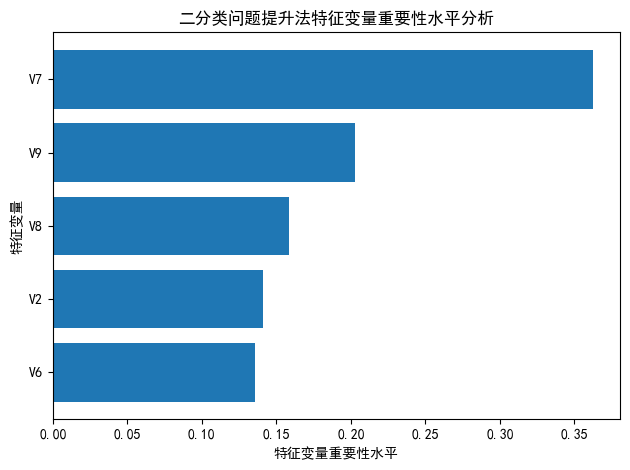

In [7]:
# 15.5  二分类问题提升法特征变量重要性水平分析
sorted_index = model.feature_importances_.argsort() #特征变量重要性排序
plt.rcParams['font.sans-serif'] = ['SimHei']#解决图表中中文显示问题
plt.barh(range(X_train.shape[1]), model.feature_importances_[sorted_index])
plt.yticks(np.arange(X_train.shape[1]), X_train.columns[sorted_index])
plt.xlabel('特征变量重要性水平')
plt.ylabel('特征变量')
plt.title('二分类问题提升法特征变量重要性水平分析')
plt.tight_layout()

/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  func(*args, **kwargs)
/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


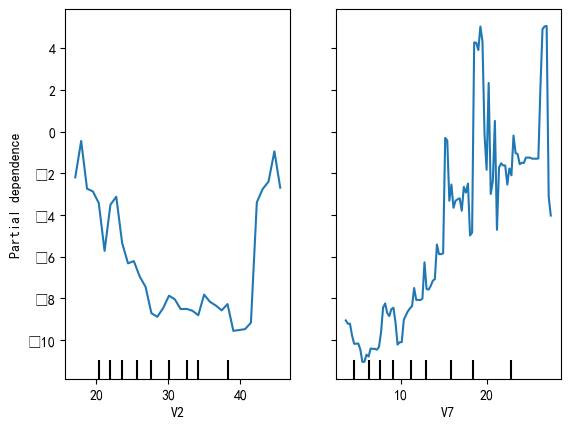

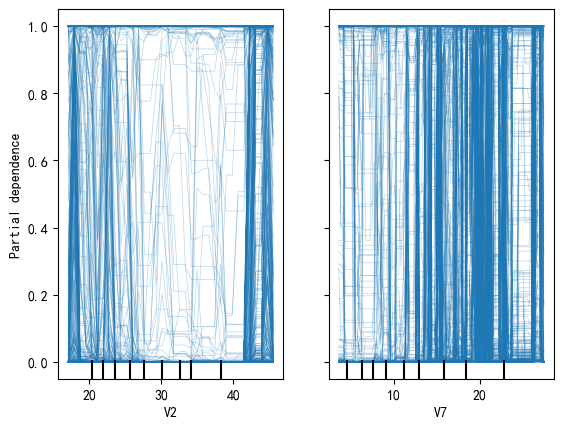

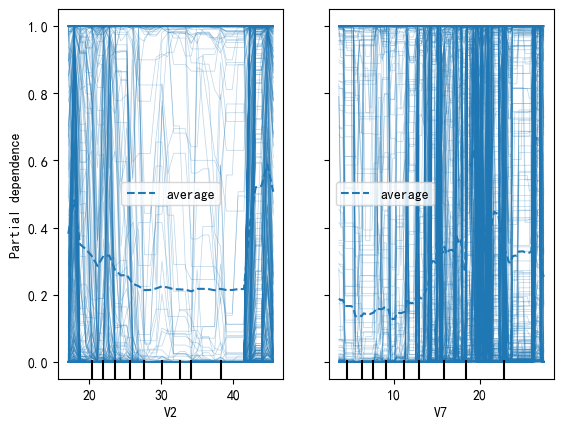

In [13]:
#15.3.6  绘制部分依赖图与个体条件期望图
PartialDependenceDisplay.from_estimator(model, X_train, ['V2','V7'],kind='average')#绘制部分依赖图简称PDP图
PartialDependenceDisplay.from_estimator(model, X_train, ['V2','V7'],kind='individual')#绘制个体条件期望图（ICE Plot）
PartialDependenceDisplay.from_estimator(model, X_train, ['V2','V7'],kind='both')#绘制个体条件期望图（ICE Plot）

In [14]:
#15.7  模型性能评价
np.set_printoptions(suppress=True)#不以科学计数法显示，而是直接显示数字
prob = model.predict_proba(X_test)# 预测概率
print(prob[:5])
pred = model.predict(X_test)#   预测类别
print(pred[:5])
print(confusion_matrix(y_test, pred))
print(classification_report(y_test,pred))
cohen_kappa_score(y_test, pred)#计算kappa得分

[[0.1228499  0.8771501 ]
 [0.03333305 0.96666695]
 [0.00008768 0.99991232]
 [0.99998808 0.00001192]
 [0.99999996 0.00000004]]
[1 1 1 0 0]
[[137  26]
 [ 28  19]]
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       163
           1       0.42      0.40      0.41        47

    accuracy                           0.74       210
   macro avg       0.63      0.62      0.62       210
weighted avg       0.74      0.74      0.74       210



0.24850894632206766

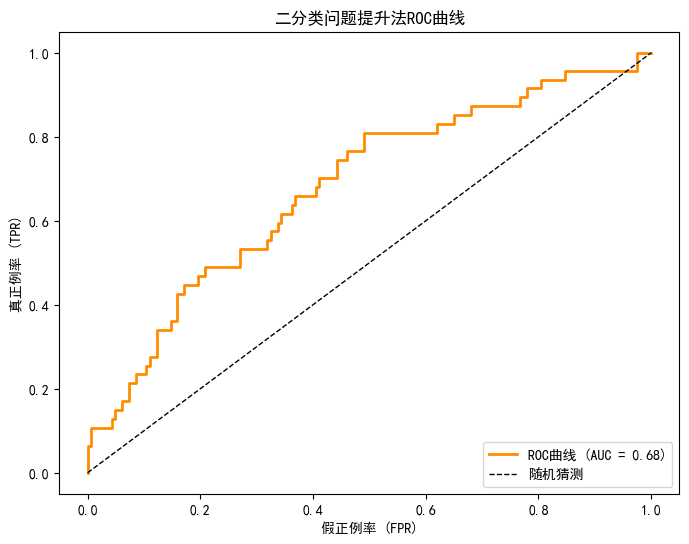

In [15]:
#15.4.8  绘制ROC曲线
# 解决中文显示问题（补充负号显示，避免负号乱码）
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

# 1. 计算模型预测概率（正例的概率）
y_pred_proba = model.predict_proba(X_test)[:, 1]  # 取第二列（正例概率）

# 2. 计算ROC曲线的FPR、TPR
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

# 3. 计算AUC（可选，用于标题显示）
roc_auc = auc(fpr, tpr)

# 4. 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC曲线 (AUC = {roc_auc:.2f})")
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), "k--", linewidth=1, label="随机猜测")

# 设置标题、坐标轴标签和图例
plt.title("二分类问题提升法ROC曲线")
plt.xlabel("假正例率 (FPR)")
plt.ylabel("真正例率 (TPR)")
plt.legend(loc="lower right")

# 显示图像
plt.show()

/Users/longmozhou/Documents/文稿 - LongMacBook Pro/深度学习/cs336/assignment1-basics/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, '二分类问题提升法决策边界')

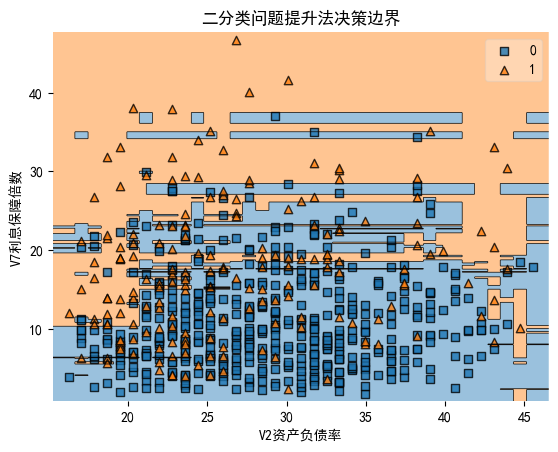

In [17]:
#15.9  运用两个特征变量绘制二分类提升法决策边界图
X2 = X.iloc[:, [0,2]]
model = GradientBoostingClassifier(random_state=123)
model.fit(X2,y)
model.score(X2,y)
plot_decision_regions(np.array(X2), np.array(y), model)
plt.xlabel('V2资产负债率')#将x轴设置为'V2'
plt.ylabel('V7利息保障倍数')#将y轴设置为'V7'
plt.title('二分类问题提升法决策边界')#将标题设置为'二分类问题提升法决策边界'


In [21]:
#15.4.10 XGBoost二分类提升法
import xgboost as xgb
model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, max_depth=6, 
         subsample=0.6, colsample_bytree=0.8, learning_rate=0.1, random_state=0) #建立模型
model.fit(X_train, y_train)
model.score(X_test, y_test)

ScoreAll = []
for n_estimators in range(1, 151):
    model =xgb.XGBClassifier(objective='binary:logistic', n_estimators=n_estimators, max_depth=6, 
         subsample=0.6, colsample_bytree=0.8, learning_rate=0.1, random_state=0)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    ScoreAll.append([n_estimators,score])
ScoreAll = np.array(ScoreAll)
print(ScoreAll)
max_score = np.where(ScoreAll==np.max(ScoreAll[:,1]))[0][0] #找出最高得分对应的索引
print("最优参数以及最高得分:",ScoreAll[max_score])  

prob = model.predict_proba(X_test)
prob[:5]
pred = model.predict(X_test)
pred[:5]
print(confusion_matrix(y_test, pred))
print(classification_report(y_test,pred))
cohen_kappa_score(y_test, pred)#计算kappa得分


[[  1.           0.77619048]
 [  2.           0.77619048]
 [  3.           0.77619048]
 [  4.           0.77619048]
 [  5.           0.77619048]
 [  6.           0.78095238]
 [  7.           0.78095238]
 [  8.           0.78095238]
 [  9.           0.8       ]
 [ 10.           0.79047619]
 [ 11.           0.8047619 ]
 [ 12.           0.8047619 ]
 [ 13.           0.81428571]
 [ 14.           0.8047619 ]
 [ 15.           0.80952381]
 [ 16.           0.80952381]
 [ 17.           0.8       ]
 [ 18.           0.78571429]
 [ 19.           0.8       ]
 [ 20.           0.8047619 ]
 [ 21.           0.8047619 ]
 [ 22.           0.80952381]
 [ 23.           0.8047619 ]
 [ 24.           0.7952381 ]
 [ 25.           0.8       ]
 [ 26.           0.8       ]
 [ 27.           0.7952381 ]
 [ 28.           0.8       ]
 [ 29.           0.8       ]
 [ 30.           0.7952381 ]
 [ 31.           0.8047619 ]
 [ 32.           0.8       ]
 [ 33.           0.8       ]
 [ 34.           0.8       ]
 [ 35.        

0.2997082117548979